#1. Entendimiento del Negocio
##Contexto General:
La calidad y el acceso a la educación en Colombia presentan disparidades significativas entre las zonas urbanas y rurales. Factores macroeconómicos como el índice de pobreza multidimensional, la infraestructura tecnológica (conectividad a internet) y los recursos asignados a las instituciones educativas juegan un rol crítico en el desempeño académico de los estudiantes.

##Objetivo del Negocio :
El objetivo principal del equipo de consultoría es diseñar un plan de acción estratégico para el Ministerio de Educación, respaldado por el análisis de datos masivos. Se busca identificar las causas subyacentes de los bajos resultados en las pruebas ICFES Saber 11 y su relación con factores territoriales, como la disponibilidad de internet y las tasas de deserción y cobertura, para proponer políticas públicas de mejora focalizadas por municipio.

#2. Selección de los Datos a Utilizar
Para el desarrollo de la primera fase del proyecto, se utilizará el conjunto de datos de educación básica y media (Estadisticas-de-Educacion-en-Preescolar-Basica-y-Media-por-Municipio.csv).

##Razón de selección: 
Este dataset permite entender la estructura base del sistema educativo territorial. Contiene variables clave como cobertura neta, deserción, aprobación y repitencia en todos los niveles escolares (transición, primaria, secundaria y media). Estas variables son fundamentales para cruzarlas posteriormente con los resultados del ICFES y el acceso a internet, permitiéndonos identificar en dónde el sistema está fallando antes de que el estudiante llegue a presentar la prueba estatal.

#3. Colección y Descripción de Datos
En este apartado inicializamos el clúster local de Apache Spark, cargamos los datos y verificamos los esquemas y significados.

In [0]:
# Importar librerías necesarias de PySpark y gráficas
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, isnan, when, count, regexp_replace, mean
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Iniciar sesión de Spark (Clúster)
spark = SparkSession.builder.appName("MinEducacion_Proyecto").getOrCreate()

# 2. Cargar el dataset asumiendo delimitador de comas 
file_path = "/Volumes/workspace/proyecto/proyectopdd/Estadísticas-de-Educación-en-Preescolar-Básica-y-Media-por-Municipio.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True, sep=",")

# 3. Mostrar los tipos de datos (Esquema)
print("--- ESQUEMA DE DATOS ---")
df.printSchema()

# 4. Descripción general del contenido
print(f"Total de registros (filas): {df.count()}")
print(f"Total de atributos (columnas): {len(df.columns)}")

--- ESQUEMA DE DATOS ---
root
 |-- AÑO: integer (nullable = true)
 |-- CÓDIGO_MUNICIPIO: integer (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- CÓDIGO_DEPARTAMENTO: integer (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- CÓDIGO_ETC: double (nullable = true)
 |-- ETC: string (nullable = true)
 |-- POBLACIÓN_5_16: double (nullable = true)
 |-- TASA_MATRICULACIÓN_5_16: string (nullable = true)
 |-- COBERTURA_NETA: string (nullable = true)
 |-- COBERTURA_NETA_TRANSICIÓN: string (nullable = true)
 |-- COBERTURA_NETA_PRIMARIA: string (nullable = true)
 |-- COBERTURA_NETA_SECUNDARIA: string (nullable = true)
 |-- COBERTURA_NETA_MEDIA: string (nullable = true)
 |-- COBERTURA_BRUTA: string (nullable = true)
 |-- COBERTURA_BRUTA_TRANSICIÓN: string (nullable = true)
 |-- COBERTURA_BRUTA_PRIMARIA: string (nullable = true)
 |-- COBERTURA_BRUTA_SECUNDARIA: string (nullable = true)
 |-- COBERTURA_BRUTA_MEDIA: string (nullable = true)
 |-- TAMAÑO_PROMEDIO_DE_GRUPO: 

## Comprensión del significado de atributos clave:

MUNICIPIO / DEPARTAMENTO: Identificadores geográficos de las entidades territoriales.

TASA_MATRICULACIÓN_5_16: Porcentaje de la población en edad escolar efectivamente matriculada.

COBERTURA_NETA / BRUTA: Indicadores de capacidad del sistema educativo por nivel (transición, primaria, etc.).

DESERCIÓN, APROBACIÓN, REPITENCIA: Tasas de rendimiento y permanencia estudiantil.

SEDES_CONECTADAS_A_INTERNET: Refleja la brecha de infraestructura digital.

#4. Exploración de los Datos
Se presentan 8 elementos exploratorios (descriptivos, agrupaciones y gráficas) para comprender la distribución de la información escolar territorial.

1. ESTADÍSTICOS DEL PANORAMA EDUCATIVO EN BOYACÁ (AÑO 2024)
+-------+-----------------+------------------+-----------------+-----------------+
|summary|   POBLACIÓN_5_16|COBERTURA_NETA_NUM|    DESERCIÓN_NUM|   APROBACIÓN_NUM|
+-------+-----------------+------------------+-----------------+-----------------+
|   mean|1896.260162601626| 80.51365869413546|2.162926821204705|92.36463413393595|
|    min|            184.0|             43.86|              0.0|            82.02|
|    max|          32210.0|            121.21|             6.25|            99.54|
+-------+-----------------+------------------+-----------------+-----------------+

2. TOP 5 MUNICIPIOS CON MAYOR DESERCIÓN ESCOLAR (2024)
+------------------+-------------+
|         MUNICIPIO|DESERCIÓN_NUM|
+------------------+-------------+
|             Togüí|         6.25|
|San Luis de Gaceno|          6.0|
|        Chitaraque|         5.17|
|            Cubará|         4.97|
|           Susacón|         4.64|
+------------------+---

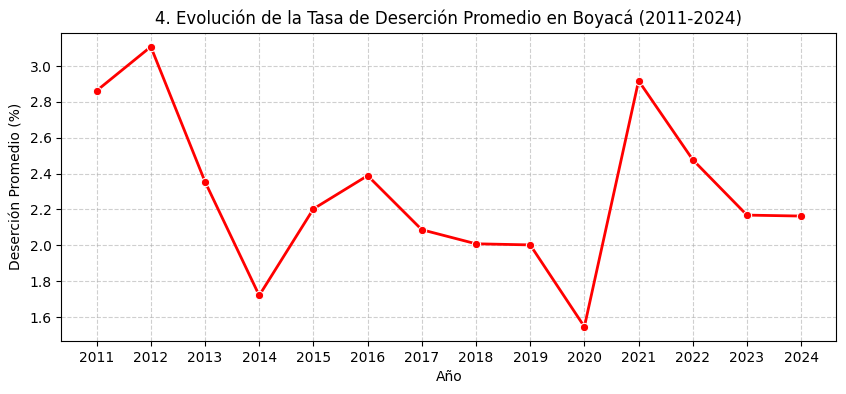

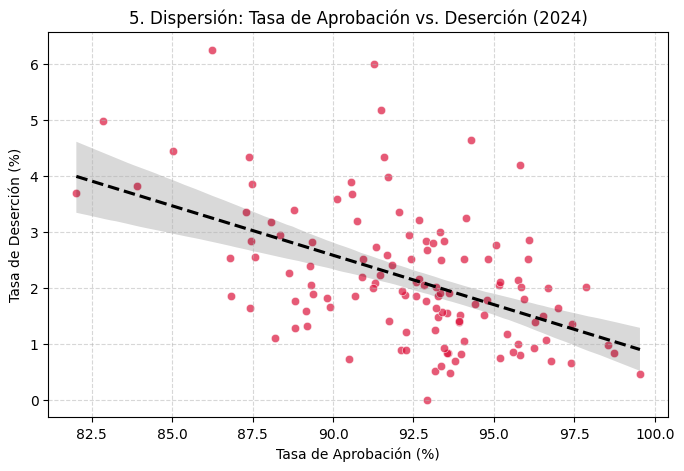

/home/spark-b87fc56a-0294-4372-be37-33/.ipykernel/2034/command-5888021274036250-2419793042:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=niveles, y=promedios_nivel, palette='viridis')


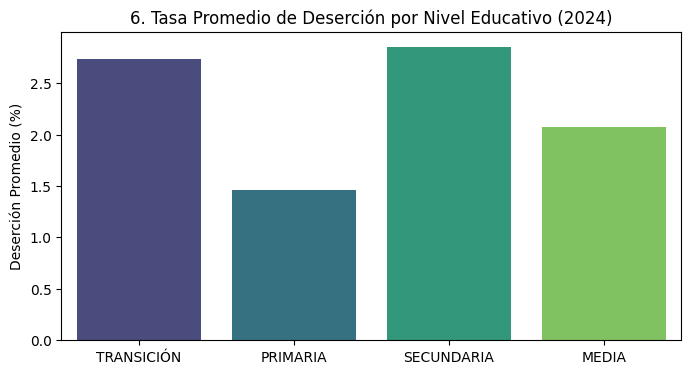

7. MATRIZ DE CORRELACIÓN ENTRE INDICADORES DE ÉXITO (2024)
                    COBERTURA_NETA_NUM  ...  REPITENCIA_NUM
COBERTURA_NETA_NUM                1.00  ...            0.06
DESERCIÓN_NUM                     0.02  ...            0.26
REPROBACIÓN_NUM                   0.14  ...            0.33
APROBACIÓN_NUM                   -0.13  ...           -0.38
REPITENCIA_NUM                    0.06  ...            1.00

[5 rows x 5 columns]


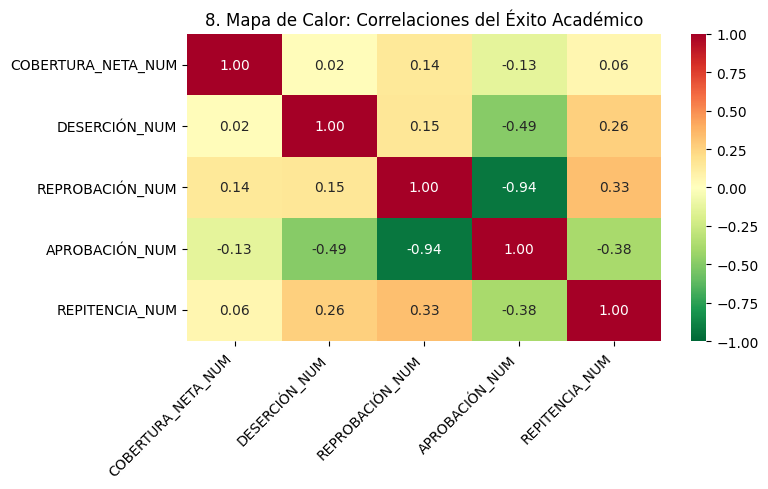

In [0]:
# Importar librerías necesarias para transformación y visualización
from pyspark.sql.functions import col, regexp_replace
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==============================================================================
# TRANSFORMACIÓN PREVIA: Limpieza de caracteres para métricas numéricas
# Convertiremos las columnas de texto con '%' y ',' a float para poder operarlas
# ==============================================================================
columnas_a_numerico = [
    'DESERCIÓN', 'COBERTURA_NETA', 'REPROBACIÓN', 'APROBACIÓN', 'REPITENCIA',
    'DESERCIÓN_TRANSICIÓN', 'DESERCIÓN_PRIMARIA', 'DESERCIÓN_SECUNDARIA', 'DESERCIÓN_MEDIA'
]

df_exp = df
for c in columnas_a_numerico:
    df_exp = df_exp.withColumn(c + "_NUM", regexp_replace(col(c), "%", ""))
    df_exp = df_exp.withColumn(c + "_NUM", regexp_replace(col(c + "_NUM"), ",", ".").cast("float"))

# Filtramos los datos para analizar el panorama más reciente (2024)
df_2024 = df_exp.filter(col("AÑO") == 2024)

# ==============================================================================
# ELEMENTO 1: Descriptivos del panorama actual (2024)
# ==============================================================================
print("1. ESTADÍSTICOS DEL PANORAMA EDUCATIVO EN BOYACÁ (AÑO 2024)")
df_2024.select("POBLACIÓN_5_16", "COBERTURA_NETA_NUM", "DESERCIÓN_NUM", "APROBACIÓN_NUM").summary("mean", "min", "max").show()

# ==============================================================================
# ELEMENTO 2: Top 5 de Municipios Críticos (Mayor deserción en 2024)
# ==============================================================================
print("2. TOP 5 MUNICIPIOS CON MAYOR DESERCIÓN ESCOLAR (2024)")
df_2024.orderBy(col("DESERCIÓN_NUM").desc()).select("MUNICIPIO", "DESERCIÓN_NUM").show(5)

# ==============================================================================
# ELEMENTO 3: Top 5 de Municipios Destacados (Mejor cobertura neta en 2024)
# ==============================================================================
print("3. TOP 5 MUNICIPIOS CON MEJOR COBERTURA NETA (2024)")
df_2024.orderBy(col("COBERTURA_NETA_NUM").desc()).select("MUNICIPIO", "COBERTURA_NETA_NUM").show(5)

# ==============================================================================
# PREPARACIÓN DE DATOS PARA GRÁFICOS (Conversión a Pandas)
# ==============================================================================
pdf_completo = df_exp.select(
    "AÑO", "MUNICIPIO", "DESERCIÓN_NUM", "COBERTURA_NETA_NUM", 
    "APROBACIÓN_NUM", "REPITENCIA_NUM", "REPROBACIÓN_NUM",
    "DESERCIÓN_TRANSICIÓN_NUM", "DESERCIÓN_PRIMARIA_NUM", 
    "DESERCIÓN_SECUNDARIA_NUM", "DESERCIÓN_MEDIA_NUM"
).toPandas()

# DataFrame de Pandas exclusivo para 2024
pdf_2024 = pdf_completo[pdf_completo['AÑO'] == 2024]

# ==============================================================================
# ELEMENTO 4: Tendencia histórica de la Deserción (2011 - 2024)
# ==============================================================================
plt.figure(figsize=(10,4))
tendencia_desercion = pdf_completo.groupby('AÑO')['DESERCIÓN_NUM'].mean()
sns.lineplot(x=tendencia_desercion.index, y=tendencia_desercion.values, marker='o', color='red', linewidth=2)
plt.title('4. Evolución de la Tasa de Deserción Promedio en Boyacá (2011-2024)')
plt.ylabel('Deserción Promedio (%)')
plt.xlabel('Año')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(tendencia_desercion.index)
plt.show()

# ==============================================================================
# ELEMENTO 5: Dispersión y Tendencia (Aprobación vs. Deserción)
# ==============================================================================
plt.figure(figsize=(8,5))
sns.scatterplot(data=pdf_2024, x='APROBACIÓN_NUM', y='DESERCIÓN_NUM', alpha=0.7, color='crimson')
# Añadir línea de tendencia
sns.regplot(data=pdf_2024, x='APROBACIÓN_NUM', y='DESERCIÓN_NUM', scatter=False, color='black', line_kws={"linestyle": "--"})
plt.title('5. Dispersión: Tasa de Aprobación vs. Deserción (2024)')
plt.xlabel('Tasa de Aprobación (%)')
plt.ylabel('Tasa de Deserción (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================================================================
# ELEMENTO 6: Brecha de Deserción por Nivel Educativo
# ==============================================================================
plt.figure(figsize=(8,4))
niveles = ['TRANSICIÓN', 'PRIMARIA', 'SECUNDARIA', 'MEDIA']
promedios_nivel = [pdf_2024[f'DESERCIÓN_{nivel}_NUM'].mean() for nivel in niveles]
sns.barplot(x=niveles, y=promedios_nivel, palette='viridis')
plt.title('6. Tasa Promedio de Deserción por Nivel Educativo (2024)')
plt.ylabel('Deserción Promedio (%)')
plt.show()

# ==============================================================================
# ELEMENTO 7: Matriz de Correlación de Indicadores Clave
# ==============================================================================
print("7. MATRIZ DE CORRELACIÓN ENTRE INDICADORES DE ÉXITO (2024)")
variables_corr = ['COBERTURA_NETA_NUM', 'DESERCIÓN_NUM', 'REPROBACIÓN_NUM', 'APROBACIÓN_NUM', 'REPITENCIA_NUM']
correlaciones = pdf_2024[variables_corr].corr()
print(correlaciones.round(2))

# ==============================================================================
# ELEMENTO 8: Heatmap visual de la Matriz de Correlación
# ==============================================================================
plt.figure(figsize=(8,5))
sns.heatmap(correlaciones, annot=True, cmap='RdYlGn_r', vmin=-1, vmax=1, fmt=".2f")
plt.title('8. Mapa de Calor: Correlaciones del Éxito Académico')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#5. Reporte de Calidad de Datos
A continuación, validamos el conteo de valores faltantes. Se ha implementado un bucle validando los tipos de datos en el esquema para evitar problemas con la lectura de nulos en columnas alfanuméricas vs numéricas.

In [0]:
print("--- REPORTE DE VALORES FALTANTES ---")

# Creamos una lista de expresiones dependiendo del tipo de dato de la columna para evitar errores de CAST
expresiones_nulos = []

for columna, tipo in df.dtypes:
    if tipo == 'string':
        # Para columnas de texto: buscamos nulos, campos vacíos o la cadena "NaN"
        condicion = col(columna).isNull() | (col(columna) == "") | (col(columna) == "NaN")
    else:
        # Para columnas numéricas: buscamos nulos o usamos isnan()
        condicion = col(columna).isNull() | isnan(columna)
        
    expresiones_nulos.append(count(when(condicion, columna)).alias(columna))

# Mostrar los valores faltantes horizontal/verticalmente
df.select(expresiones_nulos).show(vertical=True)

--- REPORTE DE VALORES FALTANTES ---
-RECORD 0--------------------------
 AÑO                         | 0   
 CÓDIGO_MUNICIPIO            | 0   
 MUNICIPIO                   | 0   
 CÓDIGO_DEPARTAMENTO         | 0   
 DEPARTAMENTO                | 0   
 CÓDIGO_ETC                  | 0   
 ETC                         | 0   
 POBLACIÓN_5_16              | 0   
 TASA_MATRICULACIÓN_5_16     | 0   
 COBERTURA_NETA              | 7   
 COBERTURA_NETA_TRANSICIÓN   | 6   
 COBERTURA_NETA_PRIMARIA     | 2   
 COBERTURA_NETA_SECUNDARIA   | 3   
 COBERTURA_NETA_MEDIA        | 7   
 COBERTURA_BRUTA             | 3   
 COBERTURA_BRUTA_TRANSICIÓN  | 0   
 COBERTURA_BRUTA_PRIMARIA    | 2   
 COBERTURA_BRUTA_SECUNDARIA  | 14  
 COBERTURA_BRUTA_MEDIA       | 19  
 TAMAÑO_PROMEDIO_DE_GRUPO    | 875 
 SEDES_CONECTADAS_A_INTERNET | 861 
 DESERCIÓN                   | 9   
 DESERCIÓN_TRANSICIÓN        | 215 
 DESERCIÓN_PRIMARIA          | 55  
 DESERCIÓN_SECUNDARIA        | 26  
 DESERCIÓN_MEDIA           

##Técnicas propuestas para tratar valores faltantes:

**Imputación por la media/mediana:** Para variables continuas de desempeño (ej. COBERTURA_NETA_PRIMARIA, DESERCIÓN_TRANSICIÓN) que presenten menos del 10% de valores faltantes, se rellenarán con la media nacional o departamental para no perder las demás métricas del municipio.

**Imputación por Agrupación Regional:** Para columnas de infraestructura como SEDES_CONECTADAS_A_INTERNET (que podrían presentar una alta tasa de vacíos), se estimará la imputación basados en el promedio de municipios con densidad poblacional similar en la misma región o departamento.

**Drop de Registros Críticos:** Si existen filas de municipios donde falten absolutamente todas las métricas de rendimiento académico (deserción, repitencia, cobertura), se descartará la fila, ya que la imputación artificial de tantas variables arruinaría la varianza del modelo para los cruces con las pruebas ICFES.

#6. Planteamiento de Preguntas sobre los Datos
De cara a la segunda fase del proyecto, plantearemos las siguientes 8 preguntas de negocio estratégicas:

¿Cuál es la relación matemática entre el número de sedes conectadas a internet de un municipio y sus tasas promedio de aprobación en educación media?

¿Cómo varía la deserción en la educación media en municipios con baja cobertura bruta frente a los de alta cobertura?

¿Cuál es el departamento con mayor tasa de repitencia en educación primaria y qué factores territoriales se asocian a este comportamiento?

¿En qué medida el tamaño promedio de grupo (hacinamiento escolar) afecta la tasa de reprobación secundaria a nivel regional?

¿Cuáles son los 10 municipios que presentan la mayor brecha de cobertura neta entre la educación primaria y la educación media?

¿Existe una correlación directa entre el nivel de pobreza de un municipio (futuro dataset a cruzar) y sus tasas de deserción escolar global?

¿Cómo ha impactado la tasa de matriculación general de la población (5 a 16 años) en la cobertura bruta específicamente en el nivel de transición?

¿Qué características demográficas y de infraestructura comparten los municipios que logran mantener tasas de reprobación menores al 3% en educación secundaria?

#7. Filtros, Limpieza y Transformación Inicial
Para poder cruzar eficientemente este conjunto de datos con los resultados del ICFES, debemos asegurarnos de que los valores de tasas (que vienen con % y comas decimales) se conviertan estrictamente a tipos numéricos, y purgar los datos atípicos o no válidos.

In [0]:
# Transformación 1: Estandarización de texto y conversión de tipos a Float
# Limpiaremos múltiples columnas que representan tasas y actualmente son string (terminan en '%')
columnas_tasas = ['COBERTURA_NETA', 'COBERTURA_BRUTA', 'DESERCIÓN_MEDIA', 'APROBACIÓN', 'REPITENCIA']

df_clean = df
for columna in columnas_tasas:
    # 1. Eliminar el símbolo de porcentaje
    df_clean = df_clean.withColumn(columna, regexp_replace(col(columna), "%", ""))
    # 2. Reemplazar comas por puntos decimales
    df_clean = df_clean.withColumn(columna, regexp_replace(col(columna), ",", "."))
    # 3. Castear la cadena a tipo numérico flotante
    df_clean = df_clean.withColumn(columna, col(columna).cast("float"))

# Filtro 1: Eliminar registros atípicos evidentes
# Descartamos municipios reportando coberturas brutas superiores al 200% asumiendo error de digitación
df_clean = df_clean.filter((col("COBERTURA_BRUTA") <= 200) | col("COBERTURA_BRUTA").isNull())

# Limpieza 1: Imputación básica de valores faltantes por la media del dataframe para la Repitencia
# (Se calcula la media omitiendo nulos y se rellena)
mean_val = df_clean.select(mean(col('REPITENCIA'))).collect()[0][0]
df_clean = df_clean.fillna({'REPITENCIA': mean_val})

print("--- MUESTRA DEL DATASET TRANSFORMADO Y LIMPIO ---")
df_clean.select("MUNICIPIO", "COBERTURA_NETA", "COBERTURA_BRUTA", "REPITENCIA").show(5)

--- MUESTRA DEL DATASET TRANSFORMADO Y LIMPIO ---
+----------+--------------+---------------+----------+
| MUNICIPIO|COBERTURA_NETA|COBERTURA_BRUTA|REPITENCIA|
+----------+--------------+---------------+----------+
|     Nobsa|        108.13|         112.88|       7.1|
|  Corrales|         94.47|          97.12|      7.18|
|Covarachía|         76.84|          81.17|      4.64|
|   Susacón|         59.34|          61.54|      8.93|
|   Macanal|         64.55|          68.09|      7.36|
+----------+--------------+---------------+----------+
only showing top 5 rows
